# News Dataset

In [ ]:
!kaggle datasets download -d emineyetm/fake-news-detection-datasets #Downloading data set from kaggle

import zipfile
with zipfile.ZipFile("fake-news-detection-datasets.zip", 'r') as zip_ref:
    zip_ref.extractall("fake_news_data")

Dataset URL: https://www.kaggle.com/datasets/emineyetm/fake-news-detection-datasets
License(s): unknown


In [ ]:
import pandas as pd

# Load the datasets
Fakedf = pd.read_csv('/content/fake_news_data/News _dataset/Fake.csv')
Truedf = pd.read_csv('/content/fake_news_data/News _dataset/True.csv')
Fakedf.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
# Add 'News_Label' column to Truedf
Truedf['News_Label'] = 0

# Add 'News_Label' column to Fakedf
Fakedf['News_Label'] = 1

# Merge both dataframes together
df = pd.concat([Truedf, Fakedf], ignore_index=True)
df.head(10)

,title,text,subject,date,News_Label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0
5,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,"December 29, 2017",0
6,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",politicsNews,"December 29, 2017",0
7,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,"December 29, 2017",0
8,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,"December 29, 2017",0
9,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,politicsNews,"December 28, 2017",0


In [ ]:
# Unique 'subject' identify values for Real news
real_subjects = df[df['News_Label'] == 1]['subject'].unique()
print("Unique subjects in Real news:")
print(real_subjects)

# Distribution of 'subject' values for Real news
real_subjects_dist = df[df['News_Label'] == 1]['subject'].value_counts()
print("\nDistribution of subjects in Real news:")
print(real_subjects_dist)

# Unique 'subject' identify  values for Fake news
fake_subjects = df[df['News_Label'] == 0]['subject'].unique()
print("\nUnique subjects in Fake news:")
print(fake_subjects)

# Distribution of 'subject'  values for Fake news
fake_subjects_dist = df[df['News_Label'] == 0]['subject'].value_counts()
print("\nDistribution of subjects in Fake news:")
print(fake_subjects_dist)

Unique subjects in Real news:
['News' 'politics' 'Government News' 'left-news' 'US_News' 'Middle-east']

Distribution of subjects in Real news:
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778
Name: count, dtype: int64

Unique subjects in Fake news:
['politicsNews' 'worldnews']

Distribution of subjects in Fake news:
subject
politicsNews    11272
worldnews       10145
Name: count, dtype: int64


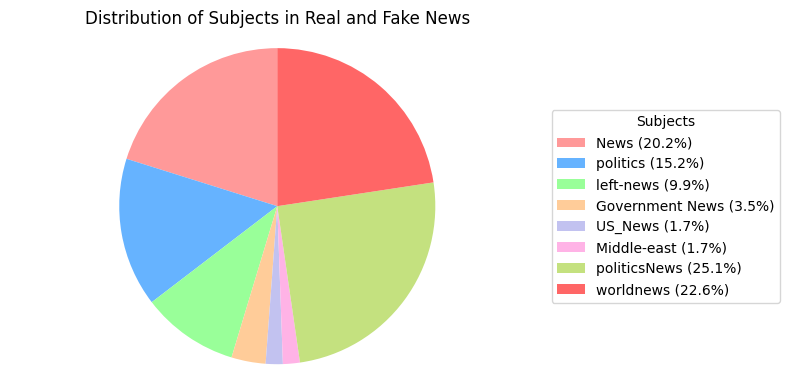

In [ ]:
import matplotlib.pyplot as plt

# Data for plotting
real_subjects_dist = {
    'News': 9050,
    'politics': 6841,
    'left-news': 4459,
    'Government News': 1570,
    'US_News': 783,
    'Middle-east': 778
}

fake_subjects_dist = {
    'politicsNews': 11272,
    'worldnews': 10145
}

# Combine real and fake news data
all_subjects = {**real_subjects_dist, **fake_subjects_dist}

# Creates labels and counts for plotting
labels = list(all_subjects.keys())
counts = list(all_subjects.values())

# Computes percentages
total = sum(counts)
percentages = [count / total * 100 for count in counts]
labels_with_pct = [f"{label} ({pct:.1f}%)" for label, pct in zip(labels, percentages)]

# Plotting
plt.figure(figsize=(8, 4))
wedges, texts = plt.pie(counts, startangle=90, colors=[
    '#ff9999', '#66b3ff', '#99ff99', '#ffcc99',
    '#c2c2f0', '#ffb3e6', '#c4e17f', '#ff6666'
])
plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.title('Distribution of Subjects in Real and Fake News')

# Adding legend with percentages
plt.legend(wedges, labels_with_pct, title="Subjects", loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

In [ ]:
# Checks for missing values
missing_percentage = df.isnull().mean() * 100
print(missing_percentage[missing_percentage > 0].round(2))

# Printing the number of duplicate rows in the DataFrame
# The 'duplicated()' function returns a boolean Series where 'True' indicates a duplicate row.
# The 'sum()' function counts the number of 'True' values in the Series, which corresponds to the number of duplicate rows.
print("Number of duplicate rows:", df.duplicated().sum())


# Removes duplicate rows from the DataFrame
# ensures that only unique rows remain in 'df' by dropping any repeated entries.
df = df.drop_duplicates()

# Checks the shape of the DataFrame after removing duplicates
# 'shape' returns a tuple: (number of rows, number of columns)
# This will give the number of rows and columns left after duplicates are removed.
print('\n Shape of Dataframe after removing duplicates\n', df.shape)

Series([], dtype: float64)
Number of duplicate rows: 0

 Shape of Dataframe after removing duplicates
 (44689, 5)


In [ ]:
!pip install huggingface_hub[hf_xet]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 MB 12.4 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total rows in dataset: 44689
🚀 Processing entire dataset...


Processing (RoBERTa): 100%|██████████| 44689/44689 [15:52<00:00, 46.94it/s]


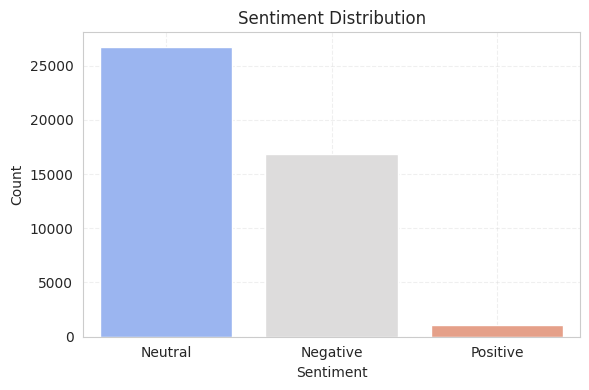

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import nltk
from nltk.corpus import stopwords
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# Downloads NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Loads sentiment analysis RoBERTa model (fine-tuned)
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Function to remove stopwords, punctuations, URLs, and numbers, and get word count
def remove_stopwords_and_measure_length(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    filtered_text = " ".join(filtered_words)
    text_length = len(filtered_words)
    return filtered_text, text_length

# Sentiment classification function
def classify_sentiment_roberta(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    pred = torch.argmax(logits, dim=-1).item()
    return ['Negative', 'Neutral', 'Positive'][pred]

# ---- Loads  dataset here ----
df = df[['text', 'subject', 'News_Label']]  # Keeps only required columns if needed

# ---- Process dataset ----
filtered_texts = []
text_lengths = []
sentiments = []

# Checks the total number of rows
print(f"Total rows in dataset: {len(df)}")

# Ensures entire dataset is processed without limiting to 1000 rows
print("Processing entire dataset...")
for text in tqdm(df['text'], desc="Processing (RoBERTa)", total=len(df)):
    filtered_text, length = remove_stopwords_and_measure_length(text)
    sentiment = classify_sentiment_roberta(filtered_text)

    filtered_texts.append(filtered_text)
    text_lengths.append(length)
    sentiments.append(sentiment)

# Add results to DataFrame
df['filtered_text'] = filtered_texts
df['text_length'] = text_lengths
df['sentiment_roberta'] = sentiments

# ---- Plots sentiment distribution ----
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment_roberta', palette='coolwarm')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Printing total count of Positive, Negative, and Neutral sentiments
sentiment_counts = df['sentiment_roberta'].value_counts()
print(f"Total Positive: {sentiment_counts.get('Positive', 0)}")
print(f"Total Negative: {sentiment_counts.get('Negative', 0)}")
print(f"Total Neutral: {sentiment_counts.get('Neutral', 0)}")

Total Positive: 1071
Total Negative: 16891
Total Neutral: 26727


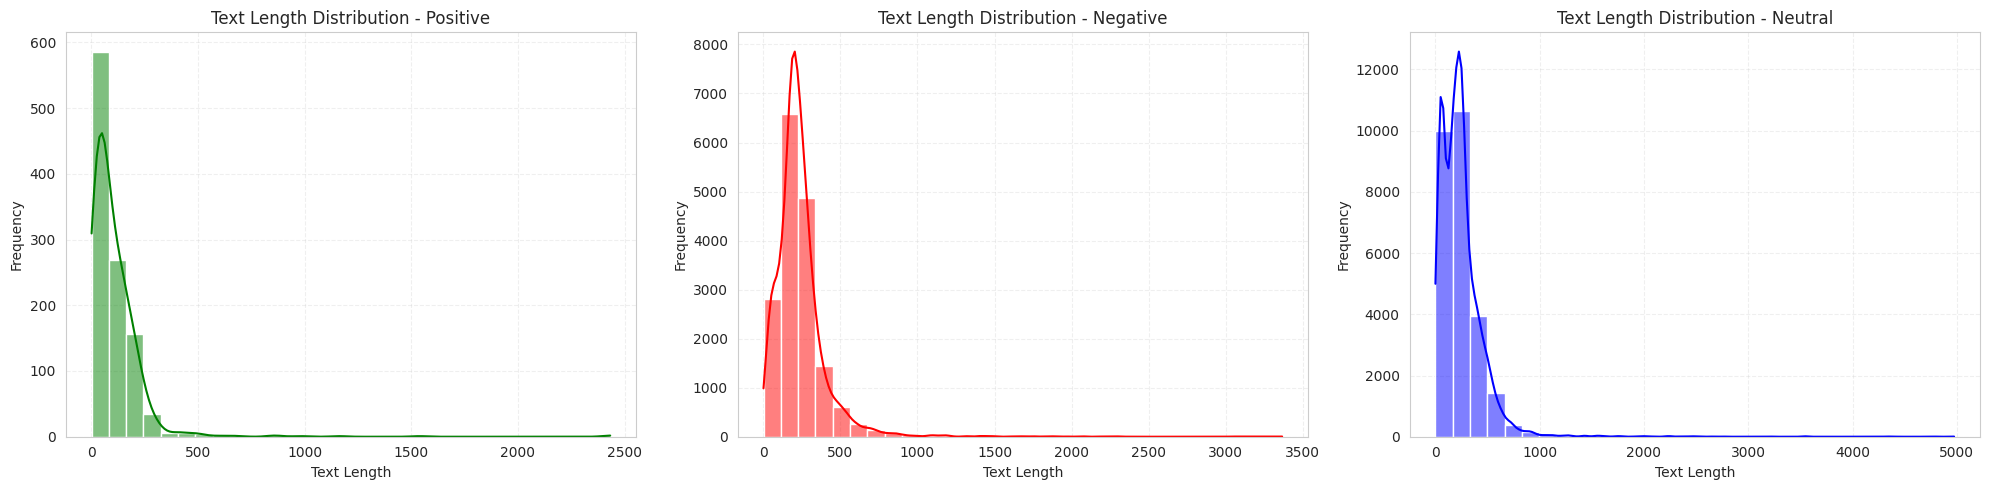

In [ ]:
# Filters text lengths based on sentiment
positive_text_lengths = df[df['sentiment_roberta'] == 'Positive']['text_length']
negative_text_lengths = df[df['sentiment_roberta'] == 'Negative']['text_length']
neutral_text_lengths = df[df['sentiment_roberta'] == 'Neutral']['text_length']

# Plot distributions of text lengths for each sentiment
plt.figure(figsize=(20, 5))

# Positive sentiments
plt.subplot(1, 3, 1)
sns.histplot(positive_text_lengths, bins=30, kde=True, color='green')
plt.title('Text Length Distribution - Positive')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.3)

# Negative sentiments
plt.subplot(1, 3, 2)
sns.histplot(negative_text_lengths, bins=30, kde=True, color='red')
plt.title('Text Length Distribution - Negative')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.3)

# Neutral sentiments
plt.subplot(1, 3, 3)
sns.histplot(neutral_text_lengths, bins=30, kde=True, color='blue')
plt.title('Text Length Distribution - Neutral')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
# Filter texts with length 50 for each sentiment
positive_50 = df[(df['sentiment_roberta'] == 'Positive') & (df['text_length'] == 50)].head(2)
negative_50 = df[(df['sentiment_roberta'] == 'Negative') & (df['text_length'] == 50)].head(2)
neutral_50 = df[(df['sentiment_roberta'] == 'Neutral') & (df['text_length'] == 50)].head(2)

# Printing two examples for each sentiment
print("Positive Sentiment Examples:")
for i, row in positive_50.iterrows():
    print(f"Text: {row['filtered_text']}")
    print(f"Sentiment: {row['sentiment_roberta']}")
    print("-" * 50)

print("Negative Sentiment Examples:")
for i, row in negative_50.iterrows():
    print(f"Text: {row['filtered_text']}")
    print(f"Sentiment: {row['sentiment_roberta']}")
    print("-" * 50)

print("Neutral Sentiment Examples:")
for i, row in neutral_50.iterrows():
    print(f"Text: {row['filtered_text']}")
    print(f"Sentiment: {row['sentiment_roberta']}")
    print("-" * 50)

Positive Sentiment Examples:
Text: WASHINGTON (Reuters) - Presumptive Republican nominee Donald Trump said Thursday “great day” Washington meeting Republican leaders, including U.S. House Representatives Speaker Paul Ryan. “Great day D.C. (Ryan) Republican leadership. Things working really well!” wrote Twitter post. meetings marked effort within Republican Party unify following contentious primary battle Republican presidential nomination.
Sentiment: Positive
--------------------------------------------------
Text: Donald Trump visiting Detroit promote agenda helping black community. good friend awesome patriot Wayne Bradley working inner city Republican office two years effort reach black community. Patty say enough great things Wayne Bradley desire succeed Republican party Michigan 2016 beyond. hard work might paying TRUMP 2016! WAYNE BRADLEY FOX NEWS:
Sentiment: Positive
--------------------------------------------------
Negative Sentiment Examples:
Text: group hackers affiliated IS

In [ ]:
# ---- Save results if needed in temporary ----
df.to_csv("sentiment_labeled_dataset.csv", index=False)

In [ ]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('/content/sentiment_labeled_dataset.csv')# deafult folder
df.rename(columns={'target': 'News_Label'}, inplace=True)

# Print column names
print(df.columns.tolist())

['text', 'subject', 'News_Label', 'filtered_text_bert', 'text_length', 'sentiment_bert', 'filtered_text', 'sentiment_roberta']


In [ ]:
# Filter rows where text length is <= 500
filtered_df = df[df['text_length'] <= 500]

# Select all Positive sentiments
positive_df = filtered_df[filtered_df['sentiment_roberta'] == 'Positive']

# Select 2000 Negative and 2000 Neutral sentiments
negative_df = filtered_df[filtered_df['sentiment_roberta'] == 'Negative'].sample(n=2000, random_state=42)
neutral_df = filtered_df[filtered_df['sentiment_roberta'] == 'Neutral'].sample(n=2000, random_state=42)

# Combine them into one DataFrame
final_df = pd.concat([positive_df, negative_df, neutral_df])

# Optionally, shuffle the resulting DataFrame
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Print the shape of the final dataset
print(f"Shape of final dataset: {final_df.shape}")

# ---- Save results if needed ----
final_df.to_csv("sentiment_labeled_dataset_2000_negat_plus_2000_neutral_1000_positive.csv", index=False)

Shape of final dataset: (5058, 8)


In [ ]:
import pandas as pd

# Loads the dataset
file_path = 'sentiment_labeled_dataset_2000_negat_plus_2000_neutral_1000_positive.csv'
df = pd.read_csv(file_path)

# Delete specified columns
df.drop(columns=['filtered_text_bert', 'text_length', 'sentiment_bert'], inplace=True)

# print remaining column names
print("Remaining Columns:")
print(df.columns.tolist())

Remaining Columns:
['text', 'subject', 'target', 'filtered_text', 'sentiment_roberta']


In [ ]:
!pip install nltk
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 11.2 MB/s eta 0:00:00


In [ ]:
!pip install contractions

## 3. Data Preprocessing
* Lower case
* Tokenization
* Removing special characters
* Removing stop words and punctuation
* Stemming

In [ ]:
import pandas as pd
import re
import nltk
import string
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
import contractions

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab') # Download the punkt_tab resource

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Defines preprocessing function
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Remove HTML
    text = BeautifulSoup(text, "html.parser").get_text()

    # Expand contractions (e.g., "isn't" -> "is not")
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove punctuation and stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words and word not in string.punctuation
    ]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

# Apply to 'filtered_text'
df['processed_text'] = df['filtered_text'].astype(str).apply(preprocess_text)

# Show sample
df[['filtered_text', 'processed_text']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
<ipython-input-3-3fa5803ffd6c>:31: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a URL than HTML or XML.

If you meant to use Beautiful Soup to parse the web page found at a certain URL, then something has gone wrong. You should use an Python package like 'requests' to fetch the content behind the URL. Once you have the content as a string, you can feed that string into Beautiful Soup.

However, if you want to parse some data that happens to look like a URL, then nothing has gone wrong: you are using Beaut

,filtered_text,processed_text
0,"Liz Harrington, writer Washington Free Beacon ...",liz harrington writer washington free beacon a...
1,(Reuters) - Mississippi’s Republican governor ...,reuters mississippi ’ republican governor said...
2,Patrick J. BuchananThat Trump presidency bedev...,patrick j. buchananthat trump presidency bedev...
3,& Grace creators David Kohan Max Mutchnick reu...,grace creator david kohan max mutchnick reunit...
4,SAN FRANCISCO (Reuters) - Russian hacking 2016...,san francisco reuters russian hacking you.s el...


### Sentiments from Clean Text

In [ ]:
df.drop(columns=['filtered_text', 'text'], inplace=True)
df.columns

Index(['subject', 'target', 'sentiment_roberta', 'processed_text'], dtype='object')

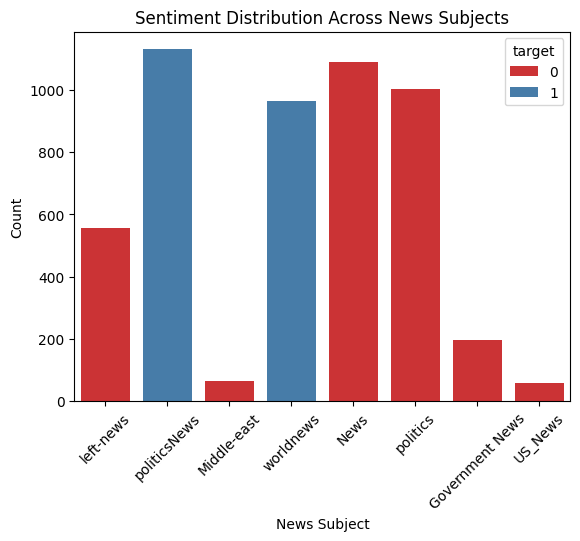

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Analyzing the distribution of sentiments across different news subjects
sns.countplot(data=df, x='subject', hue='target', palette='Set1')
plt.title('Sentiment Distribution Across News Subjects')
plt.xlabel('News Subject')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

<ipython-input-8-1e22909b7e7f>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subject_sentiment, x='subject', y='sentiment_polarity', palette='coolwarm')


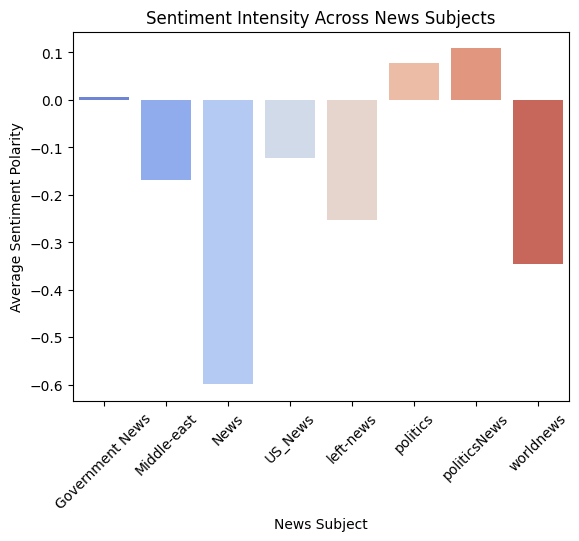

In [ ]:
# Sentiments polarity score using a simple mapping (for example purposes)
df['sentiment_polarity'] = df['sentiment_roberta'].map({'Negative': -1, 'Neutral': 0, 'Positive': 1})

# Group by news subject and calculate average sentiment polarity
subject_sentiment = df.groupby('subject')['sentiment_polarity'].mean().reset_index()

# Visualizes sentiment polarity intensity across subjects
sns.barplot(data=subject_sentiment, x='subject', y='sentiment_polarity', palette='coolwarm')
plt.title('Sentiment Intensity Across News Subjects')
plt.xlabel('News Subject')
plt.ylabel('Average Sentiment Polarity')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.columns

Index(['subject', 'target', 'sentiment_roberta', 'processed_text',
       'sentiment_polarity'],
      dtype='object')


=== Complex RNN ===
Epoch 1/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.3805 - loss: 1.1606 - val_accuracy: 0.4272 - val_loss: 1.0610
Epoch 2/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.3652 - loss: 1.1357 - val_accuracy: 0.4667 - val_loss: 1.0499
Epoch 3/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.3919 - loss: 1.1001 - val_accuracy: 0.4469 - val_loss: 1.0408
Epoch 4/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.3813 - loss: 1.0937 - val_accuracy: 0.3877 - val_loss: 1.0742
Epoch 5/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.3892 - loss: 1.0943 - val_accuracy: 0.4148 - val_loss: 1.0747
Epoch 6/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.3766 - loss: 1.0824 - val_accuracy: 0.4074 - val_loss: 1.0450
Epoch 7/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4084 - loss: 1.0657 - val_accuracy: 0.4420 - val_loss: 1.0345
Epoch 8/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.4169

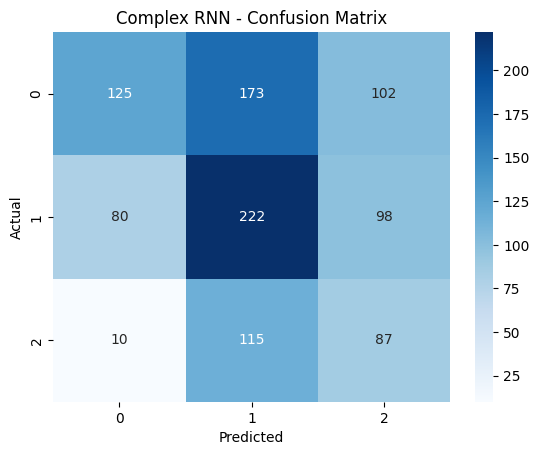


=== Complex LSTM ===
Epoch 1/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.4013 - loss: 1.0809 - val_accuracy: 0.3901 - val_loss: 1.0414
Epoch 2/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.3957 - loss: 1.0252 - val_accuracy: 0.4148 - val_loss: 0.9616
Epoch 3/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4019 - loss: 0.9965 - val_accuracy: 0.4790 - val_loss: 0.9254
Epoch 4/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.4470 - loss: 0.9803 - val_accuracy: 0.4815 - val_loss: 0.9552
Epoch 5/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.4197 - loss: 0.9757 - val_accuracy: 0.4889 - val_loss: 0.9252
Epoch 6/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4643 - loss: 0.9308 - val_accuracy: 0.4049 - val_loss: 0.9872
Epoch 7/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4679 - loss: 0.9252 - val_accuracy: 0.5136 - val_loss: 0.8880
Epoch 8/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5137 - l

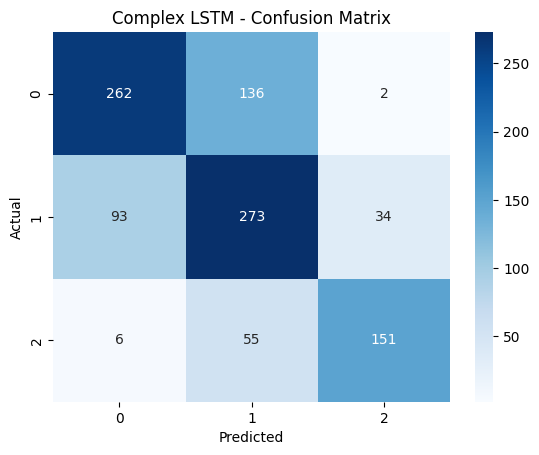

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, TextVectorization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Selects and prepare data
df = df[['processed_text', 'sentiment_polarity']]
X = df['processed_text'].astype(str)
y = pd.get_dummies(df['sentiment_polarity']).values  # one-hot encode

# Splits
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Text vectorization
max_features = 5000
sequence_length = 200

vectorizer = TextVectorization(max_tokens=max_features, output_sequence_length=sequence_length)
vectorizer.adapt(X_train_text)

X_train = vectorizer(np.array([[s] for s in X_train_text])).numpy()
X_test = vectorizer(np.array([[s] for s in X_test_text])).numpy()

# Complex RNN model
def build_complex_rnn():
    model = Sequential([
        Embedding(max_features, 128),
        SimpleRNN(128, return_sequences=True),
        Dropout(0.3),
        SimpleRNN(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Complex LSTM model
def build_complex_lstm():
    model = Sequential([
        Embedding(max_features, 128),
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Model dictionary
models = {
    'Complex RNN': build_complex_rnn(),
    'Complex LSTM': build_complex_lstm()
}

# Train and evaluate
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Text preprocessing for LSTM, RNN
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Selects relevant columns
df = df[['processed_text', 'sentiment_polarity']]

# Features and labels
X = df['processed_text']
y = df['sentiment_polarity']

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)


=== Random Forest ===
              precision    recall  f1-score   support

          -1       0.70      0.82      0.76       400
           0       0.70      0.71      0.71       400
           1       0.89      0.58      0.71       212

    accuracy                           0.73      1012
   macro avg       0.77      0.71      0.73      1012
weighted avg       0.74      0.73      0.73      1012



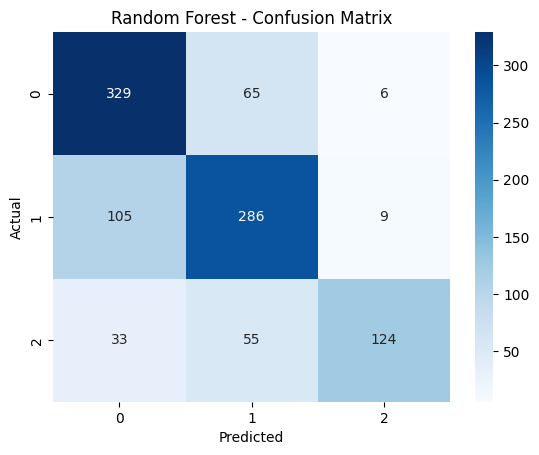


=== Logistic Regression ===
              precision    recall  f1-score   support

          -1       0.75      0.81      0.78       400
           0       0.72      0.74      0.73       400
           1       0.92      0.74      0.82       212

    accuracy                           0.77      1012
   macro avg       0.80      0.76      0.78      1012
weighted avg       0.77      0.77      0.77      1012



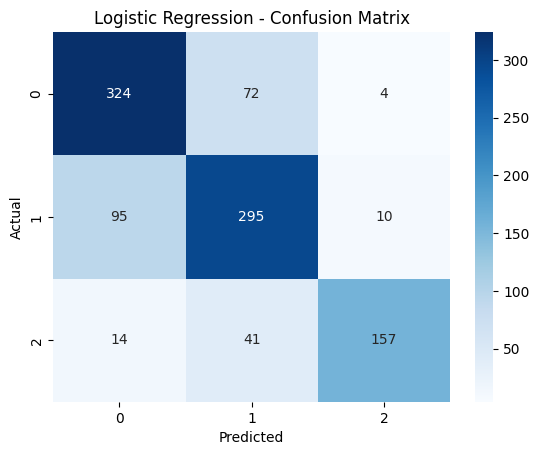


=== Naive Bayes ===
              precision    recall  f1-score   support

          -1       0.65      0.77      0.70       400
           0       0.64      0.72      0.68       400
           1       0.95      0.41      0.57       212

    accuracy                           0.67      1012
   macro avg       0.75      0.63      0.65      1012
weighted avg       0.71      0.67      0.67      1012



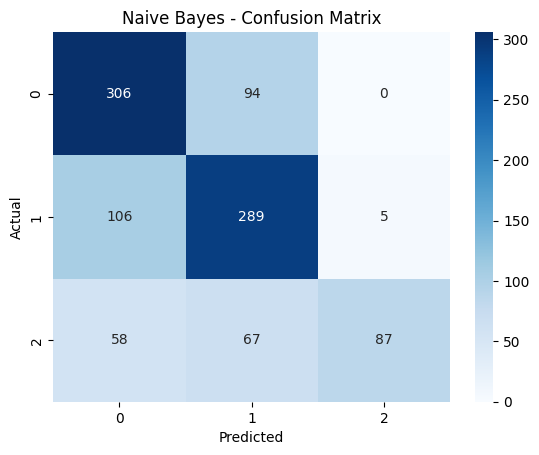


=== Decision Tree ===
              precision    recall  f1-score   support

          -1       0.66      0.66      0.66       400
           0       0.63      0.62      0.63       400
           1       0.68      0.69      0.68       212

    accuracy                           0.65      1012
   macro avg       0.66      0.66      0.66      1012
weighted avg       0.65      0.65      0.65      1012



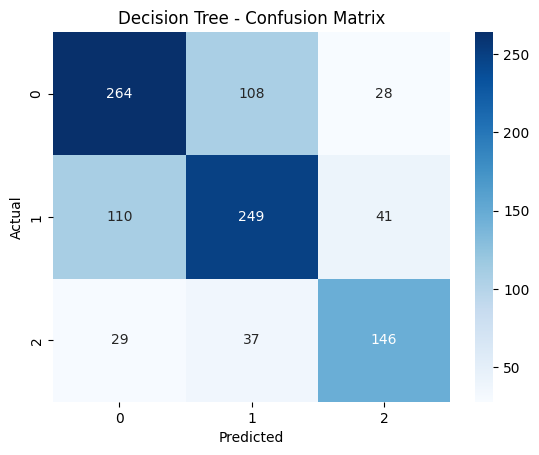

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)}

# Train & evaluate each model
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


=== Random Forest ===
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

          -1       0.69      0.79      0.74       400
           0       0.69      0.70      0.70       400
           1       0.90      0.60      0.72       212

    accuracy                           0.72      1012
   macro avg       0.76      0.70      0.72      1012
weighted avg       0.73      0.72      0.72      1012



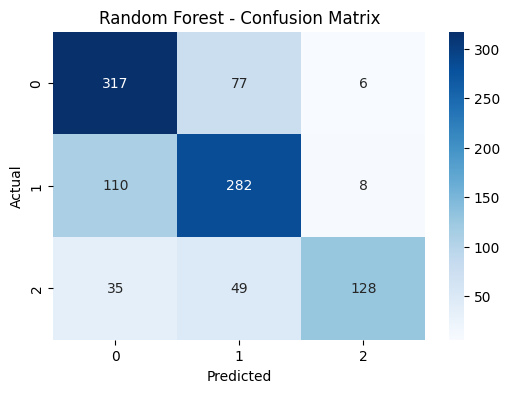


=== Logistic Regression ===
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Best parameters for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
              precision    recall  f1-score   support

          -1       0.77      0.82      0.79       400
           0       0.73      0.74      0.74       400
           1       0.91      0.78      0.84       212

    accuracy                           0.78      1012
   macro avg       0.80      0.78      0.79      1012
weighted avg       0.78      0.78      0.78      1012



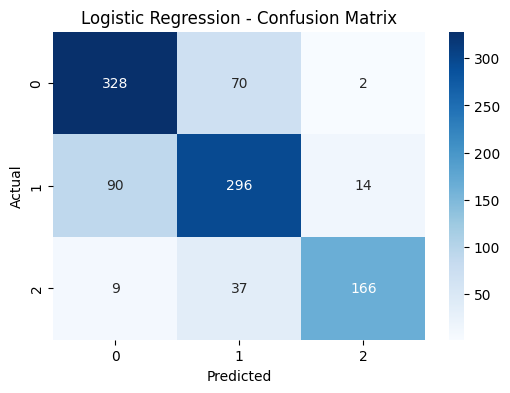


=== Naive Bayes ===
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters for Naive Bayes: {'alpha': 0.1}
              precision    recall  f1-score   support

          -1       0.69      0.77      0.73       400
           0       0.67      0.70      0.69       400
           1       0.91      0.63      0.74       212

    accuracy                           0.72      1012
   macro avg       0.76      0.70      0.72      1012
weighted avg       0.73      0.72      0.72      1012



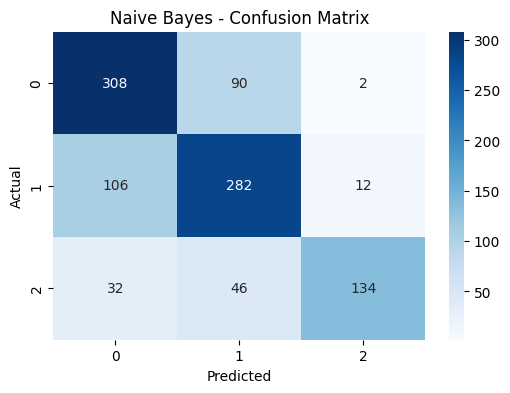


=== Decision Tree ===
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters for Decision Tree: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
              precision    recall  f1-score   support

          -1       0.68      0.65      0.67       400
           0       0.58      0.73      0.65       400
           1       0.80      0.50      0.61       212

    accuracy                           0.65      1012
   macro avg       0.69      0.63      0.64      1012
weighted avg       0.67      0.65      0.65      1012



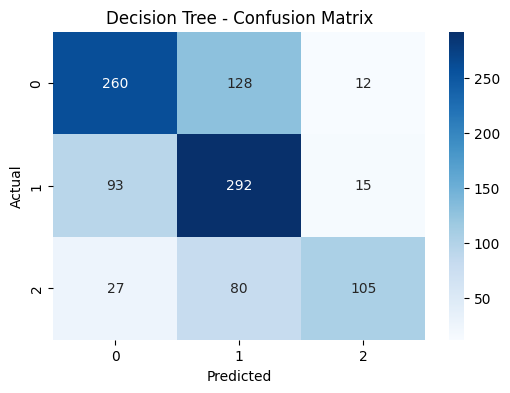

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Select relevant columns
df = df[['processed_text', 'sentiment_polarity']]

# Features and labels
X = df['processed_text']
y = df['sentiment_polarity']

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Define models and their parameter grids for tuning
models_and_params = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            'n_estimators': [100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
    },
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, n_jobs=-1),
        "params": {
            'C': [0.01, 0.1, 1, 10],
            'solver': ['lbfgs', 'liblinear'],
            'penalty': ['l2']
        }
    },
    "Naive Bayes": {
        "model": MultinomialNB(),
        "params": {
            'alpha': [0.1, 0.5, 1.0]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
    }
}

# Function to tune, train and evaluate models
def tune_and_evaluate(models_and_params):
    for name, mp in models_and_params.items():
        print(f"\n=== {name} ===")
        model = mp["model"]
        params = mp["params"]

        grid = GridSearchCV(model, params, cv=3, n_jobs=-1, scoring='accuracy', verbose=1)
        grid.fit(X_train, y_train)

        print(f"Best parameters for {name}: {grid.best_params_}")

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)

        print(classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{name} - Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

tune_and_evaluate(models_and_params)